In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from torch.autograd import Variable
import os
import torchvision
import torchvision.transforms as transforms

from torch.nn import CrossEntropyLoss, Dropout, Softmax, Linear, Conv2d, LayerNorm
import matplotlib.pyplot as plt
from torchsummary import summary

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
width    = 28
height   = 28
channels = 1
epochs   = 1000

img_shape = (width, height, channels)

In [4]:
os.makedirs(os.path.join(os.getcwd(), 'Ex16', 'data'), exist_ok = True)
data_dir = os.path.join(os.getcwd(), 'Ex16', 'data')

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = torchvision.datasets.MNIST(root = data_dir, train = True, download = True, transform = transform)
test_dataset = torchvision.datasets.MNIST(root = data_dir, train = False, transform = transform)


In [6]:
train_loader = torch.utils.data.DataLoader(dataset = train_dataset, batch_size = 128)
test_loader = torch.utils.data.DataLoader(dataset = test_dataset, batch_size = 128)

In [7]:
next(iter(train_loader))

[tensor([[[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           ...,
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],
 
 
         [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           ...,
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
           [-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242]]],
 
 
         [[[-0.4242, -0.4242, -0.4242,  ..., -0.4242, -0.4242, -0.4242],
       

In [8]:
test_show_images = next(iter(train_loader))[0]
test_targets = next(iter(train_loader))[1]

In [9]:
test_show_images = test_show_images[:10]
test_show_images = test_show_images.permute(0,2,3,1)
test_targets = test_targets[:10]

In [10]:
# unnormalize
test_show_images = (test_show_images * 0.3081) + 0.1307
test_show_images = test_show_images.numpy()
test_targets = test_targets.numpy()

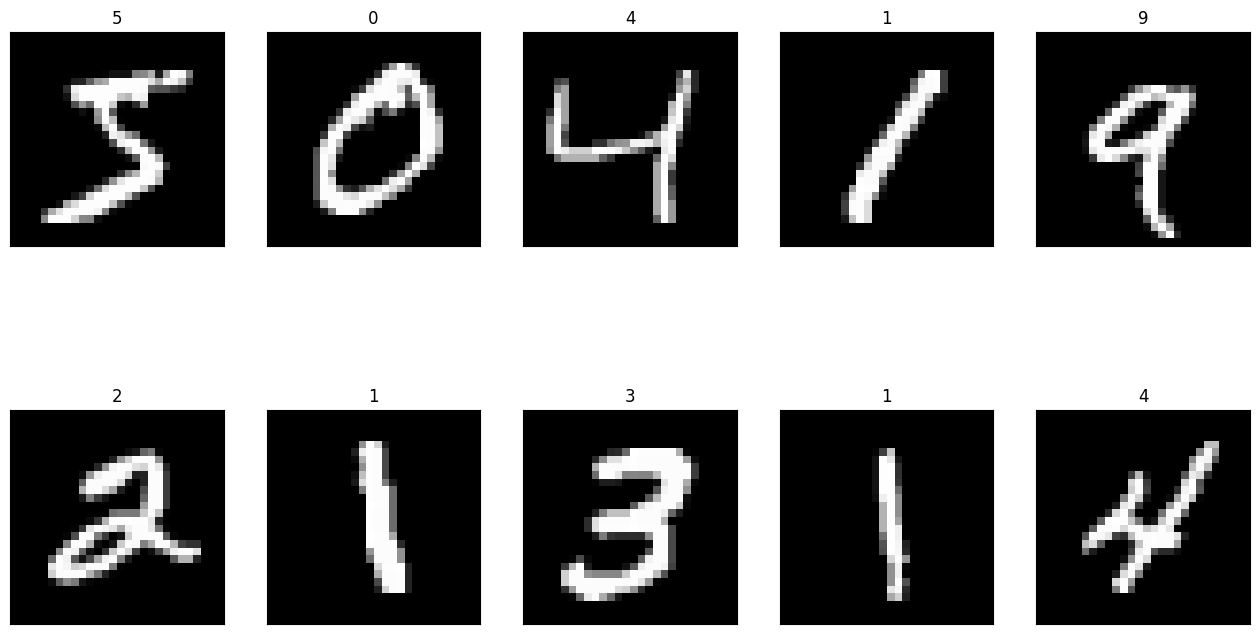

In [11]:
# plot the shit
plt.figure(figsize = (16,9))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.title(f'{test_targets[i]}')
    plt.imshow(test_show_images[i], cmap = 'gray')
    plt.xticks([])
    plt.yticks([])

trong các cấu trúc khác thường thì batch norm được đặt trước các lớp non linear(các hàm kích hoạt) và sau các lớp linear nhưng trong gan người ta thường đặt batch norm cuối cùng sau cả linear và non linear

In [12]:
class Generator(nn.Module):
    def __init__(self, noise_dim = 100, gen_dim = 784):
        super().__init__()
        self.noise_dim = 100
        self.linear1 = nn.Linear(noise_dim, 256)
        self.leakrelu = nn.LeakyReLU()
        self.bn1 = nn.BatchNorm1d(num_features = 256)
        self.linear2 = nn.Linear(256, 512)
        self.bn2 = nn.BatchNorm1d(num_features = 512)
        self.linear3 = nn.Linear(512, 1024)
        self.bn3 = nn.BatchNorm1d(num_features = 1024)
        self.linear4 = nn.Linear(1024, gen_dim) # 28*28*1 = 784
        self.tanh = nn.Tanh() # sử dụng để nén thông tin về khoảng -1 1
    
    def forward(self, X):
        X = self.leakrelu(self.linear1(X))
        X = self.bn1(X)
        X = self.leakrelu(self.linear2(X))
        X = self.bn2(X)
        X = self.leakrelu(self.linear3(X))
        X = self.bn3(X)
        X = self.linear4(X)
        X = self.tanh(X)
        return X

# Leaky Relu:
* 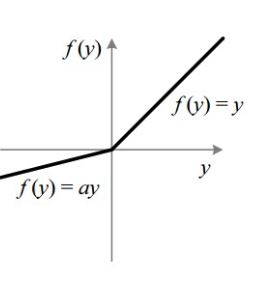

In [13]:
# test thử
gen = Generator()
gen(torch.rand(3,100)).shape

torch.Size([3, 784])

In [14]:
class Discriminator(nn.Module):
    def __init__(self, gen_dim = 784, dropout = 0.3):
        super().__init__()
        self.linear1 = nn.Linear(gen_dim, 1024)
        self.leakrelu = nn.LeakyReLU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(1024, 512)
        self.linear3 = nn.Linear(512, 256)
        self.linear4 = nn.Linear(256,1)
    
    def forward(self, X):
        X = self.linear1(X)
        X = self.leakrelu(X)
        X = self.dropout(X)
        X = self.leakrelu(self.linear2(X))
        X = self.leakrelu(self.linear3(X))
        X = self.linear4(X)
        return X
    # đầu ra là xác suất ảnh thật

In [15]:
gen = Generator()
dis = Discriminator()
gen_outputs = gen(torch.rand(3,100))
dis_outputs = dis(gen_outputs)
dis_outputs.shape

torch.Size([3, 1])

sử dụng hàm loss nn.BCEWithLogitsLoss 
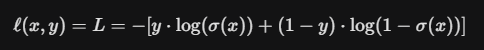. Đối với discriminator thì sẽ là loss của logit đầu ra và nhãn của nó, đối với generator thì loss sẽ là đầu ra của discrim với ảnh giả vừa gen và 1 (cố tính gán ảnh giả là ảnh thật nếu discrim không tin thì loss cao)

In [20]:
from tqdm import tqdm
gen = Generator().to(device)
dis = Discriminator().to(device)

gen_optimizer = torch.optim.Adam(gen.parameters(), lr = 1e-4)
dis_optimizer = torch.optim.Adam(dis.parameters(), lr = 1e-4)

criterion = nn.BCEWithLogitsLoss()
epochs = 10

losses_G = []
losses_D = []
samples = []

for epoch in range(epochs):
    for i, (imgs, _) in tqdm(enumerate(train_loader)):
        imgs = imgs.reshape(-1,784)
        imgs = imgs.to(device)
        # dữ liệu khi đi qua discrim có dạng là batch_size,1, tạo các nhãn theo shape đó
        valid_targets = torch.full((imgs.size(0), 1), 0.85, device=device)
        fake_targets = torch.zeros((imgs.size(0),1), device = device)
        real_imgs = imgs.type(torch.float32)
        
        # train generator
        # tạo img pha ke
        gen_optimizer.zero_grad()
        fake_imgs = torch.randn((imgs.size(0), 100), device = device)
        output_gen = gen(fake_imgs)
        loss_gen = criterion(dis(output_gen), valid_targets)
        loss_gen.backward()
        gen_optimizer.step()

        # train discriminator
        dis_optimizer.zero_grad()
        fake_imgs = torch.randn((imgs.size(0), 100), device = device)
        output_gen = gen(fake_imgs).detach()
        blend_imgs = torch.cat((real_imgs, output_gen), dim = 0)
        output_dis = dis(blend_imgs)
        loss_dis = criterion(output_dis, torch.cat((valid_targets, fake_targets), dim = 0))
        loss_dis.backward()
        dis_optimizer.step()

        if(i == len(train_loader)-1):
            print(f'[Epoch: {epoch}], [G_loss: {loss_gen.item()}], [D_loss: {loss_dis.item()}] ')
            losses_G.append(loss_gen.item())
            losses_D.append(loss_dis.item())
            samples.append(output_gen)

469it [00:06, 77.16it/s]


[Epoch: 0], [G_loss: 2.851351737976074], [D_loss: 0.4163666367530823] 


469it [00:06, 77.95it/s]


[Epoch: 1], [G_loss: 4.472590446472168], [D_loss: 0.40388092398643494] 


469it [00:05, 78.24it/s]


...

[Epoch: 7], [G_loss: 5.864293575286865], [D_loss: 0.27686548233032227] 


469it [00:06, 76.42it/s]


[Epoch: 8], [G_loss: 6.1837897300720215], [D_loss: 0.22980976104736328] 


469it [00:06, 77.36it/s]

[Epoch: 9], [G_loss: 6.430458068847656], [D_loss: 0.22564539313316345] 


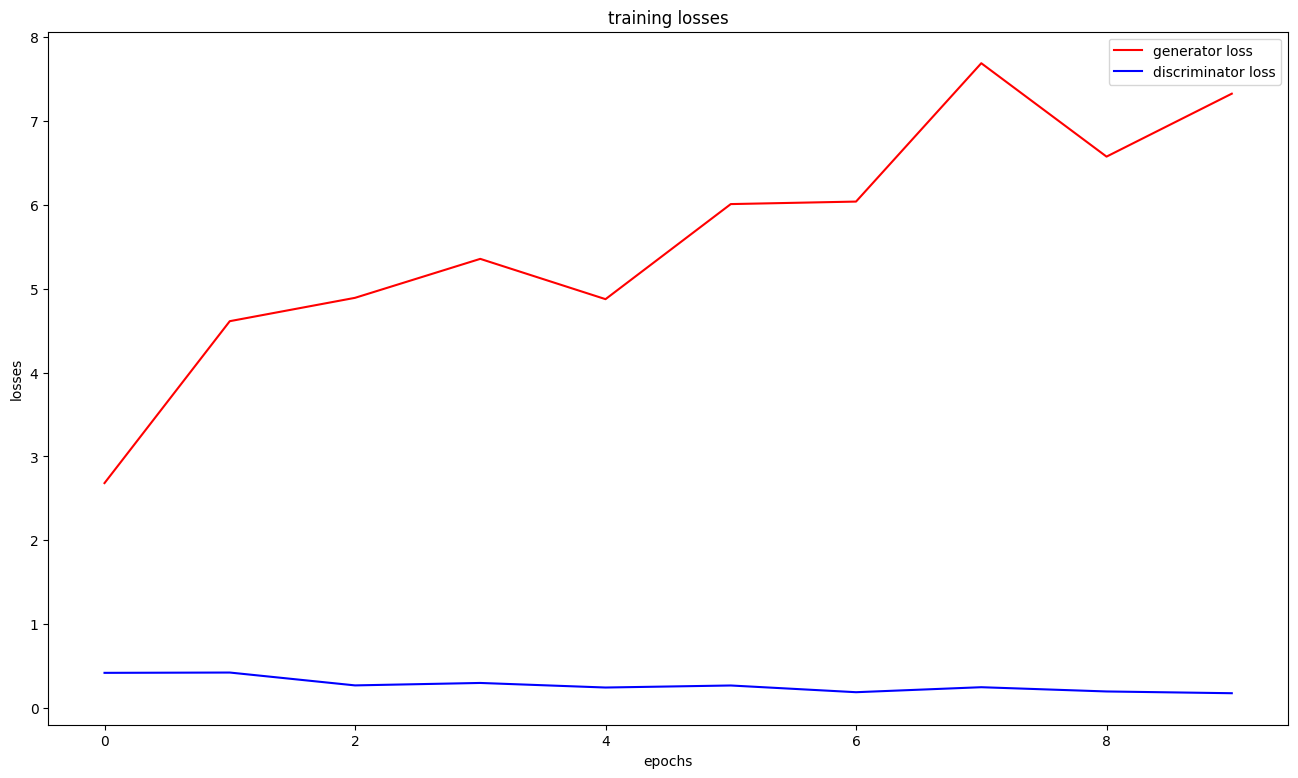

In [17]:
plt.figure(figsize = (16,9))
plt.title('training losses')
plt.plot(range(len(losses_G)), losses_G, color = 'r', label = 'generator loss')
plt.plot(range(len(losses_D)), losses_D, color = 'b', label = 'discriminator loss')
plt.xlabel('epochs')
plt.ylabel('losses')
plt.legend(loc = 'best')

In [18]:
noise = torch.randn(16,100, device = device)
fake = gen(noise)
fake = fake.reshape(16,1,28,28)
fake = fake.permute(0,2,3,1).detach().cpu().numpy()

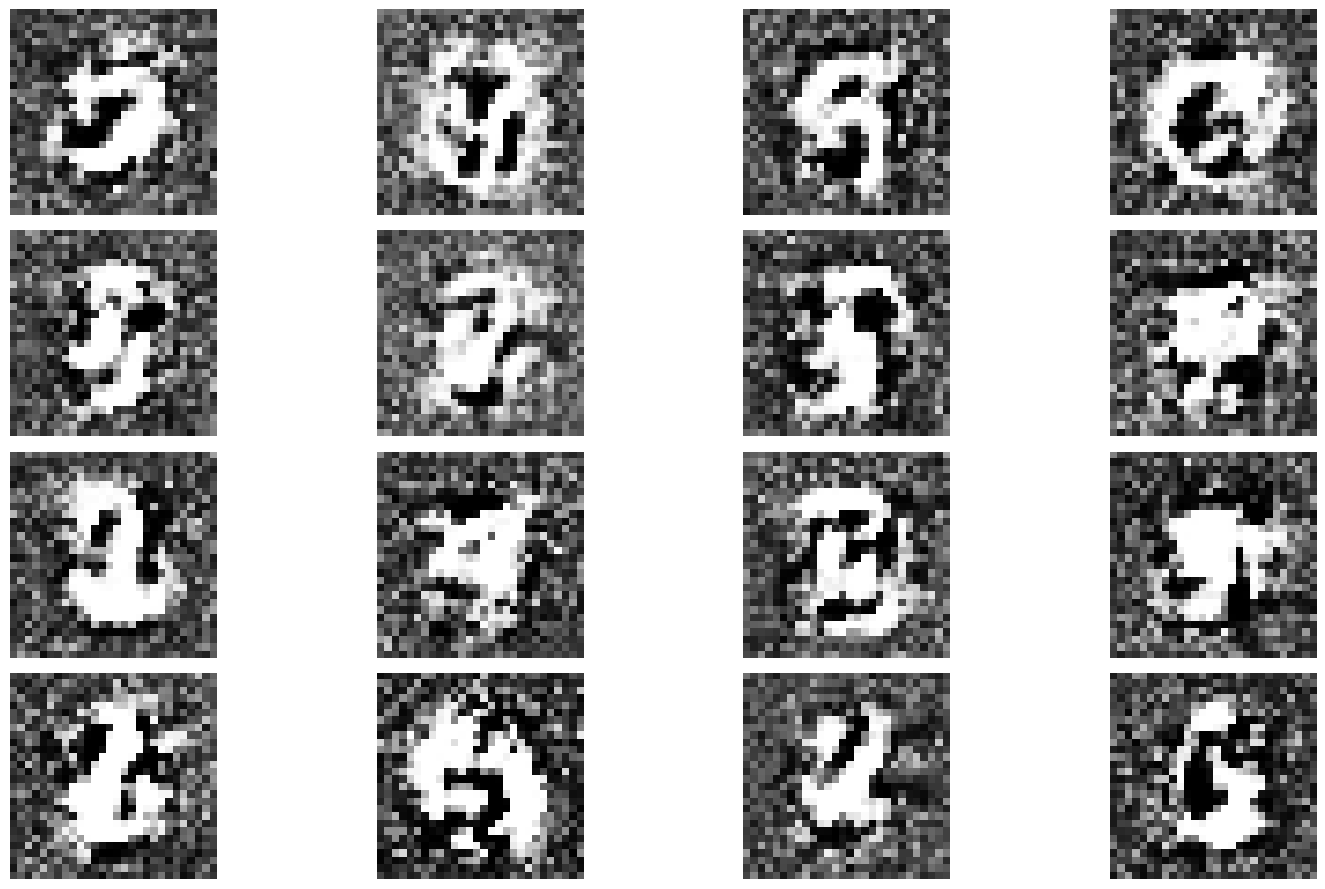

In [19]:
plt.figure(figsize = (16,9))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(fake[i], cmap = 'gray')
    plt.axis('off')
plt.tight_layout()